# NB18 — SHGAT Beam Rescoring Analysis

**Question**: Est-ce que le SHGAT peut rescorer les candidats beam du GRU pour améliorer le ranking ?

**Hypothèse**: Le GRU est bon en cohérence séquentielle (transitions), le SHGAT est bon en pertinence intent→tool (scoring global). Combiner les deux scores devrait améliorer le 1st@1.

**Méthode**:
1. Pour chaque trace test, le GRU produit K candidats beam avec scores
2. Pour chaque candidat, on calcule un score SHGAT (cosine intent → enriched tool emb)
3. Score final = α·GRU + (1-α)·SHGAT, sweep sur α
4. Comparer 1st@1, First-N avant/après rescoring

**Data**: JSON généré par `dump-beam-for-rescore.ts`

In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Load beam data
with open('18-beam-rescore-data.json', 'r') as f:
    data = json.load(f)

# Filter to traces with valid actualPath (>= 2 tools)
all_results = data['results']
results = [r for r in all_results if len(r.get('actualPath', [])) >= 2]
beam_width = data['beamWidth']
print(f"Loaded {len(all_results)} total traces, {len(results)} with valid actualPath (>= 2 tools)")
print(f"Beam width: {beam_width}, Seed: {data['seed']}")
print(f"Beam candidates per trace: {Counter(len(r['beamCandidates']) for r in results)}")

Loaded 56 total traces, 24 with valid actualPath (>= 2 tools)
Beam width: 5, Seed: 42
Beam candidates per trace: Counter({10: 24})


## 1. Baseline — GRU beam ranking sans rescoring

In [8]:
def path_first_n(pred, actual):
    """Check if predicted path matches actual for min(len) first elements."""
    min_len = min(len(pred), len(actual))
    return all(pred[i] == actual[i] for i in range(min_len))

def path_exact(pred, actual):
    return len(pred) == len(actual) and all(pred[i] == actual[i] for i in range(len(pred)))

def first_tool_hit(pred_path, actual_path):
    return len(pred_path) > 0 and len(actual_path) > 0 and pred_path[0] == actual_path[0]

def evaluate_ranking(results, score_fn=None, label="Baseline"):
    """Evaluate beam ranking with optional rescoring function.
    
    score_fn: (trace_result, beam_idx) -> float  (higher = better)
    If None, uses original GRU ordering.
    """
    first1 = 0
    first_n = 0
    exact = 0
    any_first1 = 0  # any beam has correct first tool
    any_first_n = 0  # any beam matches first-N
    total = 0
    rank_of_best = []  # rank of best beam candidate (0-indexed)
    
    for r in results:
        if len(r['beamCandidates']) == 0:
            continue
        total += 1
        actual = r['actualPath']
        
        # Get beam candidates with scores
        candidates = list(enumerate(r['beamCandidates']))
        
        if score_fn:
            # Rescore and re-rank
            scored = [(i, score_fn(r, i)) for i, _ in candidates]
            scored.sort(key=lambda x: -x[1])  # descending
            candidates = [(i, r['beamCandidates'][i]) for i, _ in scored]
        
        # Top-1 after (re)ranking
        top_path = candidates[0][1]['path']
        if first_tool_hit(top_path, actual):
            first1 += 1
        if path_first_n(top_path, actual):
            first_n += 1
        if path_exact(top_path, actual):
            exact += 1
        
        # Any beam candidate matches?
        found_first1 = False
        found_first_n = False
        best_rank = -1
        for rank, (orig_idx, beam) in enumerate(candidates):
            if first_tool_hit(beam['path'], actual) and not found_first1:
                found_first1 = True
            if path_first_n(beam['path'], actual) and not found_first_n:
                found_first_n = True
                best_rank = rank
        if found_first1:
            any_first1 += 1
        if found_first_n:
            any_first_n += 1
            rank_of_best.append(best_rank)
    
    print(f"\n=== {label} ===")
    print(f"  Top-1 first tool:   {first1}/{total} ({first1/total*100:.1f}%)")
    print(f"  Top-1 First-N:      {first_n}/{total} ({first_n/total*100:.1f}%)")
    print(f"  Top-1 Exact:        {exact}/{total} ({exact/total*100:.1f}%)")
    print(f"  Any beam 1st tool:  {any_first1}/{total} ({any_first1/total*100:.1f}%)")
    print(f"  Any beam First-N:   {any_first_n}/{total} ({any_first_n/total*100:.1f}%)")
    if rank_of_best:
        print(f"  Best rank (when hit): mean={np.mean(rank_of_best):.2f}, median={np.median(rank_of_best):.1f}")
    
    return {
        'label': label,
        'first1': first1/total*100,
        'first_n': first_n/total*100,
        'exact': exact/total*100,
        'any_first1': any_first1/total*100,
        'any_first_n': any_first_n/total*100,
        'total': total,
    }

# Baseline: original GRU beam ranking
baseline = evaluate_ranking(results, score_fn=None, label="GRU Beam (baseline)")


=== GRU Beam (baseline) ===
  Top-1 first tool:   14/24 (58.3%)
  Top-1 First-N:      8/24 (33.3%)
  Top-1 Exact:        4/24 (16.7%)
  Any beam 1st tool:  14/24 (58.3%)
  Any beam First-N:   12/24 (50.0%)
  Best rank (when hit): mean=1.92, median=0.0


## 2. SHGAT Rescoring — sweep sur alpha

In [9]:
import io, contextlib

# Normalize GRU scores per trace (min-max) for fair combination
def normalize_scores(scores):
    if len(scores) <= 1:
        return [1.0] * len(scores)
    mn, mx = min(scores), max(scores)
    if mx - mn < 1e-10:
        return [1.0] * len(scores)
    return [(s - mn) / (mx - mn) for s in scores]

# Different SHGAT scoring strategies
def shgat_mean_score(r, beam_idx):
    """Mean SHGAT cosine similarity across all tools in path."""
    return r['shgatMeanPerBeam'][beam_idx]

def shgat_first_score(r, beam_idx):
    """SHGAT score of first tool only."""
    return r['shgatFirstPerBeam'][beam_idx]

def shgat_max_score(r, beam_idx):
    """Max SHGAT score across tools in path."""
    scores = r['shgatScoresPerBeam'][beam_idx]
    return max(scores) if scores else 0

def shgat_weighted_score(r, beam_idx):
    """Weighted SHGAT: first tool gets 2x weight."""
    scores = r['shgatScoresPerBeam'][beam_idx]
    if not scores:
        return 0
    weights = [2.0] + [1.0] * (len(scores) - 1)
    return sum(s * w for s, w in zip(scores, weights)) / sum(weights)

# Sweep alpha for combined scoring
alphas = np.arange(0.0, 1.05, 0.05)
shgat_strategies = {
    'mean': shgat_mean_score,
    'first': shgat_first_score,
    'max': shgat_max_score,
    'weighted_first_2x': shgat_weighted_score,
}

sweep_results_clean = {}
for strat_name, shgat_fn in shgat_strategies.items():
    sweep_results_clean[strat_name] = []
    for alpha in alphas:
        def combined_score(r, beam_idx, _alpha=alpha, _shgat_fn=shgat_fn):
            gru_scores = [b['gruScore'] for b in r['beamCandidates']]
            gru_norm = normalize_scores(gru_scores)
            shgat_scores_all = [_shgat_fn(r, i) for i in range(len(r['beamCandidates']))]
            shgat_norm = normalize_scores(shgat_scores_all)
            return _alpha * gru_norm[beam_idx] + (1 - _alpha) * shgat_norm[beam_idx]
        
        with contextlib.redirect_stdout(io.StringIO()):
            metrics = evaluate_ranking(results, score_fn=combined_score, label=f"{strat_name} α={alpha:.2f}")
        sweep_results_clean[strat_name].append((alpha, metrics))

print("Sweep complete!")
for strat_name in shgat_strategies:
    best = max(sweep_results_clean[strat_name], key=lambda x: x[1]['first_n'])
    print(f"  {strat_name}: best First-N={best[1]['first_n']:.1f}% at α={best[0]:.2f} (1st@1={best[1]['first1']:.1f}%)")

Sweep complete!
  mean: best First-N=33.3% at α=0.65 (1st@1=58.3%)
  first: best First-N=33.3% at α=0.00 (1st@1=58.3%)
  max: best First-N=33.3% at α=0.70 (1st@1=58.3%)
  weighted_first_2x: best First-N=33.3% at α=0.60 (1st@1=58.3%)


## 3. Visualisation — First-N et 1st@1 vs alpha

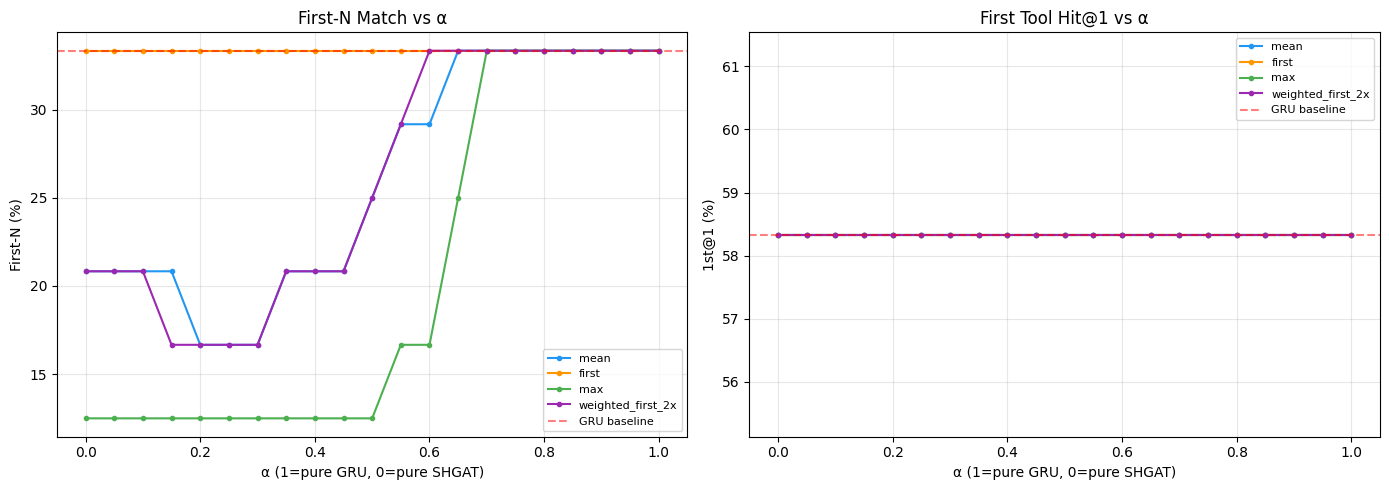

Saved to 18-shgat-beam-rescoring.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'mean': '#2196F3', 'first': '#FF9800', 'max': '#4CAF50', 'weighted_first_2x': '#9C27B0'}

for strat_name in shgat_strategies:
    data_points = sweep_results_clean[strat_name]
    xs = [d[0] for d in data_points]
    
    # First-N
    ys_fn = [d[1]['first_n'] for d in data_points]
    axes[0].plot(xs, ys_fn, '-o', color=colors[strat_name], label=strat_name, markersize=3)
    
    # 1st@1
    ys_f1 = [d[1]['first1'] for d in data_points]
    axes[1].plot(xs, ys_f1, '-o', color=colors[strat_name], label=strat_name, markersize=3)

# Baseline lines
axes[0].axhline(y=baseline['first_n'], color='red', linestyle='--', alpha=0.5, label='GRU baseline')
axes[1].axhline(y=baseline['first1'], color='red', linestyle='--', alpha=0.5, label='GRU baseline')

axes[0].set_xlabel('α (1=pure GRU, 0=pure SHGAT)')
axes[0].set_ylabel('First-N (%)')
axes[0].set_title('First-N Match vs α')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('α (1=pure GRU, 0=pure SHGAT)')
axes[1].set_ylabel('1st@1 (%)')
axes[1].set_title('First Tool Hit@1 vs α')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('18-shgat-beam-rescoring.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to 18-shgat-beam-rescoring.png")

## 4. Best configs détaillées

In [11]:
print("=" * 70)
print("BEST CONFIGURATIONS")
print("=" * 70)

# Baseline
print(f"\nBaseline (GRU only):")
print(f"  1st@1={baseline['first1']:.1f}%  First-N={baseline['first_n']:.1f}%  Exact={baseline['exact']:.1f}%")
print(f"  Any beam 1st@1={baseline['any_first1']:.1f}%  Any beam First-N={baseline['any_first_n']:.1f}%")

print(f"\nBest rescoring configs:")
for strat_name in shgat_strategies:
    # Best by First-N
    best_fn = max(sweep_results_clean[strat_name], key=lambda x: x[1]['first_n'])
    # Best by 1st@1
    best_f1 = max(sweep_results_clean[strat_name], key=lambda x: x[1]['first1'])
    
    delta_fn = best_fn[1]['first_n'] - baseline['first_n']
    delta_f1 = best_f1[1]['first1'] - baseline['first1']
    
    print(f"\n  {strat_name}:")
    print(f"    Best First-N: α={best_fn[0]:.2f} → {best_fn[1]['first_n']:.1f}% ({delta_fn:+.1f}pp)  1st@1={best_fn[1]['first1']:.1f}%")
    print(f"    Best 1st@1:   α={best_f1[0]:.2f} → {best_f1[1]['first1']:.1f}% ({delta_f1:+.1f}pp)  First-N={best_f1[1]['first_n']:.1f}%")

BEST CONFIGURATIONS

Baseline (GRU only):
  1st@1=58.3%  First-N=33.3%  Exact=16.7%
  Any beam 1st@1=58.3%  Any beam First-N=50.0%

Best rescoring configs:

  mean:
    Best First-N: α=0.65 → 33.3% (+0.0pp)  1st@1=58.3%
    Best 1st@1:   α=0.00 → 58.3% (+0.0pp)  First-N=20.8%

  first:
    Best First-N: α=0.00 → 33.3% (+0.0pp)  1st@1=58.3%
    Best 1st@1:   α=0.00 → 58.3% (+0.0pp)  First-N=33.3%

  max:
    Best First-N: α=0.70 → 33.3% (+0.0pp)  1st@1=58.3%
    Best 1st@1:   α=0.00 → 58.3% (+0.0pp)  First-N=12.5%

  weighted_first_2x:
    Best First-N: α=0.60 → 33.3% (+0.0pp)  1st@1=58.3%
    Best 1st@1:   α=0.00 → 58.3% (+0.0pp)  First-N=20.8%


## 5. Analyse qualitative — Cas où le rescoring change le résultat

In [12]:
# Find the best strategy/alpha combo
best_overall = None
best_score = 0
for strat_name in shgat_strategies:
    for alpha, metrics in sweep_results_clean[strat_name]:
        # Optimize for First-N primarily
        score = metrics['first_n'] + 0.5 * metrics['first1']
        if score > best_score:
            best_score = score
            best_overall = (strat_name, alpha, metrics)

if best_overall:
    strat_name, alpha, _ = best_overall
    shgat_fn = shgat_strategies[strat_name]
    print(f"Best overall: {strat_name}, α={alpha:.2f}")
    print(f"\n{'='*80}")
    print(f"Cases where rescoring FIXES the ranking (GRU wrong → rescored correct):")
    print(f"{'='*80}")
    
    fixes = []
    breaks = []
    
    for r in results:
        if len(r['beamCandidates']) == 0:
            continue
        actual = r['actualPath']
        
        # GRU original top-1
        gru_top = r['beamCandidates'][0]['path']
        gru_hit = path_first_n(gru_top, actual)
        
        # Rescored top-1
        gru_scores = [b['gruScore'] for b in r['beamCandidates']]
        gru_norm = normalize_scores(gru_scores)
        shgat_scores_all = [shgat_fn(r, i) for i in range(len(r['beamCandidates']))]
        shgat_norm = normalize_scores(shgat_scores_all)
        combined = [alpha * g + (1 - alpha) * s for g, s in zip(gru_norm, shgat_norm)]
        best_idx = max(range(len(combined)), key=lambda i: combined[i])
        rescored_top = r['beamCandidates'][best_idx]['path']
        rescored_hit = path_first_n(rescored_top, actual)
        
        if not gru_hit and rescored_hit:
            fixes.append(r)
        elif gru_hit and not rescored_hit:
            breaks.append(r)
    
    print(f"\nFixes: {len(fixes)} traces rescued")
    for r in fixes[:10]:
        actual = r['actualPath']
        gru_top = r['beamCandidates'][0]['path']
        
        gru_scores = [b['gruScore'] for b in r['beamCandidates']]
        gru_norm = normalize_scores(gru_scores)
        shgat_scores_all = [shgat_fn(r, i) for i in range(len(r['beamCandidates']))]
        shgat_norm = normalize_scores(shgat_scores_all)
        combined = [alpha * g + (1 - alpha) * s for g, s in zip(gru_norm, shgat_norm)]
        best_idx = max(range(len(combined)), key=lambda i: combined[i])
        
        print(f"  Actual:      {' -> '.join(actual)}")
        print(f"  GRU top-1:   {' -> '.join(gru_top)} (score={r['beamCandidates'][0]['gruScore']:.4f})")
        print(f"  Rescored:    {' -> '.join(r['beamCandidates'][best_idx]['path'])} (beam #{best_idx})")
        shgat_top3 = [f"{x['nodeId']}({x['score']:.3f})" for x in r['shgatTop5'][:3]]
        print(f"  SHGAT top-3: {', '.join(shgat_top3)}")
        print()
    
    print(f"\nBreaks: {len(breaks)} traces broken by rescoring")
    for r in breaks[:5]:
        actual = r['actualPath']
        gru_top = r['beamCandidates'][0]['path']
        
        gru_scores = [b['gruScore'] for b in r['beamCandidates']]
        gru_norm = normalize_scores(gru_scores)
        shgat_scores_all = [shgat_fn(r, i) for i in range(len(r['beamCandidates']))]
        shgat_norm = normalize_scores(shgat_scores_all)
        combined = [alpha * g + (1 - alpha) * s for g, s in zip(gru_norm, shgat_norm)]
        best_idx = max(range(len(combined)), key=lambda i: combined[i])
        
        print(f"  Actual:     {' -> '.join(actual)}")
        print(f"  GRU (ok):   {' -> '.join(gru_top)}")
        print(f"  Rescored:   {' -> '.join(r['beamCandidates'][best_idx]['path'])} (beam #{best_idx})")
        print()
    
    print(f"\nNet impact: {len(fixes) - len(breaks):+d} traces ({len(fixes)} fixes - {len(breaks)} breaks)")
else:
    print("No improvement found with any strategy/alpha combination")

Best overall: mean, α=0.65

Cases where rescoring FIXES the ranking (GRU wrong → rescored correct):

Fixes: 0 traces rescued

Breaks: 0 traces broken by rescoring

Net impact: +0 traces (0 fixes - 0 breaks)


## 6. SHGAT-only rescoring (no GRU score)

In [13]:
print("Pure SHGAT rescoring (ignore GRU beam scores, re-rank by SHGAT only):")
print()

for strat_name, shgat_fn in shgat_strategies.items():
    with contextlib.redirect_stdout(io.StringIO()):
        metrics = evaluate_ranking(results, score_fn=shgat_fn, label=f"Pure SHGAT ({strat_name})")
    delta_fn = metrics['first_n'] - baseline['first_n']
    delta_f1 = metrics['first1'] - baseline['first1']
    print(f"  {strat_name:20s}: 1st@1={metrics['first1']:5.1f}% ({delta_f1:+.1f}pp)  First-N={metrics['first_n']:5.1f}% ({delta_fn:+.1f}pp)")

Pure SHGAT rescoring (ignore GRU beam scores, re-rank by SHGAT only):

  mean                : 1st@1= 58.3% (+0.0pp)  First-N= 20.8% (-12.5pp)
  first               : 1st@1= 58.3% (+0.0pp)  First-N= 33.3% (+0.0pp)
  max                 : 1st@1= 58.3% (+0.0pp)  First-N= 12.5% (-20.8pp)
  weighted_first_2x   : 1st@1= 58.3% (+0.0pp)  First-N= 20.8% (-12.5pp)


## 7. Oracle — upper bound (best beam candidate per trace)

In [14]:
oracle_first1 = 0
oracle_first_n = 0
oracle_exact = 0
total = 0

for r in results:
    if len(r['beamCandidates']) == 0:
        continue
    total += 1
    actual = r['actualPath']
    
    for beam in r['beamCandidates']:
        if first_tool_hit(beam['path'], actual):
            oracle_first1 += 1
            break
    
    for beam in r['beamCandidates']:
        if path_first_n(beam['path'], actual):
            oracle_first_n += 1
            break
    
    for beam in r['beamCandidates']:
        if path_exact(beam['path'], actual):
            oracle_exact += 1
            break

print(f"Oracle (best possible beam selection):")
print(f"  1st@1:   {oracle_first1}/{total} ({oracle_first1/total*100:.1f}%)")
print(f"  First-N: {oracle_first_n}/{total} ({oracle_first_n/total*100:.1f}%)")
print(f"  Exact:   {oracle_exact}/{total} ({oracle_exact/total*100:.1f}%)")
print(f"\nBaseline → Oracle gap (room for improvement):")
print(f"  1st@1:   {baseline['first1']:.1f}% → {oracle_first1/total*100:.1f}% (gap={oracle_first1/total*100 - baseline['first1']:.1f}pp)")
print(f"  First-N: {baseline['first_n']:.1f}% → {oracle_first_n/total*100:.1f}% (gap={oracle_first_n/total*100 - baseline['first_n']:.1f}pp)")

Oracle (best possible beam selection):
  1st@1:   14/24 (58.3%)
  First-N: 12/24 (50.0%)
  Exact:   7/24 (29.2%)

Baseline → Oracle gap (room for improvement):
  1st@1:   58.3% → 58.3% (gap=0.0pp)
  First-N: 33.3% → 50.0% (gap=16.7pp)


In [15]:
# For each trace, look at SHGAT score variance across beam candidates
print("SHGAT score variance across beam candidates per trace:")
print(f"{'Trace':>6} | {'Mean SHGAT':>10} | {'Std':>8} | {'Range':>8} | {'1st tool':>12} | Actual 1st")
print("-" * 80)

for i, r in enumerate(results):
    means = r['shgatMeanPerBeam']
    firsts = r['shgatFirstPerBeam']
    actual = r['actualPath']
    gru_first = r['gruFirstTool']
    
    mean_val = np.mean(means)
    std_val = np.std(means)
    range_val = max(means) - min(means)
    
    print(f"{i:6d} | {mean_val:10.4f} | {std_val:8.5f} | {range_val:8.5f} | {gru_first:>12} | {actual[0] if actual else '?'}")

print(f"\nAverage SHGAT score range across beams: {np.mean([max(r['shgatMeanPerBeam'])-min(r['shgatMeanPerBeam']) for r in results]):.5f}")
print(f"Average GRU score range across beams:   {np.mean([max(b['gruScore'] for b in r['beamCandidates'])-min(b['gruScore'] for b in r['beamCandidates']) for r in results]):.4f}")

# Are all beams starting with the same tool? 
print(f"\n--- Beam diversity ---")
for i, r in enumerate(results[:10]):
    first_tools = [b['path'][0] for b in r['beamCandidates']]
    unique = len(set(first_tools))
    print(f"  Trace {i}: {unique} unique first tools across {len(first_tools)} beams: {set(first_tools)}")

SHGAT score variance across beam candidates per trace:
 Trace | Mean SHGAT |      Std |    Range |     1st tool | Actual 1st
--------------------------------------------------------------------------------
     0 |     0.8214 |  0.03411 |  0.12111 | std:color_random | std:color_random
     1 |     0.8214 |  0.03411 |  0.12111 | std:color_random | std:color_random
     2 |     0.7555 |  0.01000 |  0.03129 | std:data_person | std:data_company
     3 |     0.7126 |  0.01049 |  0.02739 | code:JSON.parse | code:filter
     4 |     0.6940 |  0.00384 |  0.01298 | filesystem:read_file | filesystem:read_file
     5 |     0.6362 |  0.00154 |  0.00539 | filesystem:read_file | filesystem:read_file
     6 |     0.6547 |  0.00459 |  0.01653 | filesystem:read_file | filesystem:read_file
     7 |     0.7054 |  0.00368 |  0.01311 | std:data_person | std:data_person
     8 |     0.8124 |  0.00823 |  0.02853 | filesystem:read_file | filesystem:read_file
     9 |     0.8137 |  0.00303 |  0.01046 | filesys

## 8. Diagnostic — Pourquoi le cosine SHGAT ne discrimine pas ?